### Libraries

In [1]:
# Color palette
DIED_COLOR="#E53935"
SURVIVED_COLOR="#1E88E5"
custom_palette=[DIED_COLOR,SURVIVED_COLOR]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
from sklearn.preprocessing import MinMaxScaler

### 1) Load Data


In [3]:
df = pd.read_csv(r'D:\Local\Mix\NTI-ML\Materials\Session 3\titanic-1.csv')

#### 1. Understand the Dataset

In [4]:
print("Shape:", df.shape)
df.info()
df.describe(include='all').T

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


#### 2. Assess Data Quality

In [5]:
# Missing values per column
missing = df.isnull().sum()
print(missing[missing > 0])

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Duplicate IDs
print("Duplicate PassengerId:", df['PassengerId'].duplicated().sum())

# Data types
print(df.dtypes)

# Constant / near-constant columns
for col in df.columns:
    if df[col].nunique() <= 1:
        print("Constant column:", col)

# High-missing columns (>40% missing)
high_missing = df.isnull().mean()[df.isnull().mean() > 0.4]
print("High-missing columns:\n", high_missing)

Age         177
Cabin       687
Embarked      2
dtype: int64
Duplicate rows: 0
Duplicate PassengerId: 0
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
High-missing columns:
 Cabin    0.771044
dtype: float64


### 2) Cleaning Data

#### 1. Drop Duplicated & Handel Missing Data

In [6]:
def clean_data(df):
    df = df.drop_duplicates()
    # Replace missing values with the median Age, grouped by Title-implied Pclass/Sex context (fallback: overall median)
    df = df.fillna({'Age': df['Age'].median()})
    # Replace missing values with the mode of each column in: 'Embarked'
    df = df.fillna({'Embarked': df['Embarked'].mode()[0]})
    # Flag cabin availability before dropping the sparse raw column
    df['Has_Cabin'] = df['Cabin'].notna().astype(int)
    df = df.drop(columns=['Cabin'])
    return df

df_clean = clean_data(df)
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [7]:
df_clean['Age'] = df_clean['Age'].clip(lower=0)  # Clip Age values to be non-negative
df_clean['Fare'] = df_clean['Fare'].clip(lower=0)  # Clip Fare values to be non-negative
df_clean = df_clean.fillna({'Fare': df_clean['Fare'].median()})
print(df_clean['Age'].min())
print(df_clean['Fare'].min())
df_clean.head()

0.42
0.0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


#### 2. Mapping & Strip

In [8]:
# Strip stray whitespace from text columns
for col in ['Name', 'Sex', 'Ticket', 'Embarked']:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Standardize Sex casing/values, in case of inconsistent raw entries
sex_mapping = {
    'male': 'male', 'Male': 'male', 'MALE': 'male', 'm': 'male',
    'female': 'female', 'Female': 'female', 'FEMALE': 'female', 'f': 'female'
}
df_clean['Sex'] = df_clean['Sex'].replace(sex_mapping)

# Map Embarked codes to readable port names for cleaner EDA labels
embarked_mapping = {
    'S': 'Southampton',
    'C': 'Cherbourg',
    'Q': 'Queenstown'
}
df_clean['Embarked'] = df_clean['Embarked'].replace(embarked_mapping)
df_clean['Embarked'].value_counts()

Embarked
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

#### 3. Logical Anomalies

In [9]:
# Identify the indices of rows with the logical anomaly
# (Age should be a positive, realistic human age)
error_indices = df_clean[(df_clean['Age'] <= 0) | (df_clean['Age'] > 100)].index

# 2. Drop the faulty rows in-place or overwrite the DataFrame
df_clean = df_clean.drop(index=error_indices)

# 3. Verify the operation and check the new shape
print(f"Successfully dropped {len(error_indices)} rows.")
print(f"Updated DataFrame shape: {df_clean.shape}")

Successfully dropped 0 rows.
Updated DataFrame shape: (891, 12)


In [10]:
# Gather all indices where family-size logic contradicts itself
anomaly_indices = df_clean[
    (df_clean['SibSp'] < 0) |
    (df_clean['Parch'] < 0) |
    (df_clean['Fare'] < 0)
].index

print(f"Number of logical anomalies found: {len(anomaly_indices)}")

# 2. Drop the anomalies if any exist
if len(anomaly_indices) > 0:
    df_clean = df_clean.drop(index=anomaly_indices)
    print(f"Successfully dropped {len(anomaly_indices)} anomaly rows.")
else:
    print("Perfect! No logical anomalies found in family-size or fare fields.")

Number of logical anomalies found: 0
Perfect! No logical anomalies found in family-size or fare fields.


In [11]:
# Identify passengers with a paid Fare of 0 despite not being obviously crew (Pclass 1-3 paying rows)
# These are flagged rather than dropped, since a handful of genuine free/complimentary tickets existed historically.
zero_fare = df_clean[df_clean['Fare'] == 0]
print(f"Zero-fare passengers flagged: {len(zero_fare)}")
print(zero_fare[['PassengerId', 'Pclass', 'Fare']])

Zero-fare passengers flagged: 15
     PassengerId  Pclass  Fare
179          180       3   0.0
263          264       1   0.0
271          272       3   0.0
277          278       2   0.0
302          303       3   0.0
413          414       2   0.0
466          467       2   0.0
481          482       2   0.0
597          598       3   0.0
633          634       1   0.0
674          675       2   0.0
732          733       2   0.0
806          807       1   0.0
815          816       1   0.0
822          823       1   0.0


#### 4. Outlier ( IQR )

In [12]:
# List of columns to handle outliers
outlier_cols = ['Fare', 'Age']

for col in outlier_cols:
    # 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    # 2. Calculate IQR
    IQR = Q3 - Q1

    # 3. Define the upper limit (we only care about upper limit since min is 0)
    upper_limit = Q3 + 1.5 * IQR

    # 4. Cap the outliers to the upper limit
    df_clean[col] = df_clean[col].clip(upper=upper_limit)

print(df_clean[outlier_cols].describe())

             Fare         Age
count  891.000000  891.000000
mean    24.046813   29.008047
std     20.481625   12.142439
min      0.000000    0.420000
25%      7.910400   22.000000
50%     14.454200   28.000000
75%     31.000000   35.000000
max     65.634400   54.500000


#### 5. Data After Cleaning

In [13]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Southampton,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,Cherbourg,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Southampton,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Southampton,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Southampton,0


In [14]:
# # Extract cleaned data to a new CSV file
# df_clean.to_csv(r'D:\Local\Mix\NTI-ML\NTI-Projects\Titanic-Project\data\titanic_cleaned.csv', index=False)

### Feature Engineering

In [15]:
# 1. Family Size
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# 2. Is Alone
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

# 3. Title (extracted from Name, grouped into common categories)
df_clean['Title'] = df_clean['Name'].str.extract(r',\s*([^\.]*)\.')
rare_titles = df_clean['Title'].value_counts()[df_clean['Title'].value_counts() < 10].index
df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')
df_clean['Title'] = df_clean['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# 4. Fare per Person
df_clean['Fare_per_Person'] = df_clean['Fare'] / df_clean['FamilySize']

# 5. Age Group
conditions_age = [
    (df_clean['Age'] <= 12),
    (df_clean['Age'] > 12) & (df_clean['Age'] <= 19),
    (df_clean['Age'] > 19) & (df_clean['Age'] <= 59),
    (df_clean['Age'] > 59)
]
choices_age = ['Child', 'Teen', 'Adult', 'Senior']
df_clean['AgeGroup'] = np.select(conditions_age, choices_age, default='Unknown')

df_clean[['FamilySize', 'IsAlone', 'Title', 'Fare_per_Person', 'AgeGroup']].head()

,FamilySize,IsAlone,Title,Fare_per_Person,AgeGroup
0,2,0,Mr,3.6250,Adult
1,2,0,Mrs,32.8172,Adult
2,1,1,Miss,7.9250,Adult
3,2,0,Mrs,26.5500,Adult
4,1,1,Mr,8.0500,Adult


### 3) EDA
*   **Build Visulization** to extract relation between target coloumn and other featuers
*   **All Questions** responded in summary field and recommendations

#### 1. Visulizations To Explore Data

**Business Question:** What is the overall survival rate, and is the target class balanced?

**Hypothesis:** N/A (data-quality / class-balance check, not a relationship hypothesis).

**Variables:** Survived (single categorical)

**Visualization choice:** Bar chart (Single Categorical).

C:\Users\Abdo Tamer\AppData\Local\Temp\ipykernel_12304\472413144.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Survived', palette=survival_colors)


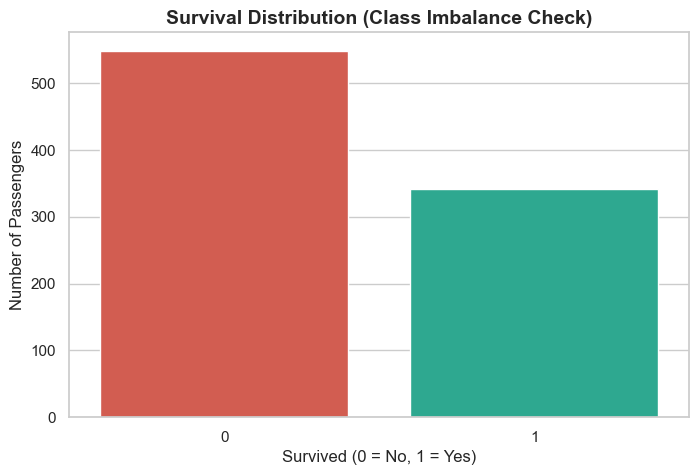

In [16]:
sns.set_theme(style="whitegrid")
# Plot 1: Target Variable Distribution (Class Imbalance Check)
plt.figure(figsize=(8, 5))

# Define a custom color palette (Red for 'Died', Teal for 'Survived') for clear contrast
survival_colors = ['#e74c3c', '#1abc9c']

# Create the countplot
sns.countplot(data=df_clean, x='Survived', palette=survival_colors)

# Add descriptive titles and labels
plt.title('Survival Distribution (Class Imbalance Check)', fontsize=14, fontweight='bold')
plt.xlabel('Survived (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Display the plot
plt.show()

**Insight:** The dataset is moderately imbalanced — passengers who died outnumber survivors.

**Implication:** Any later modeling on this data should account for class imbalance (e.g., stratified sampling, resampling, or class weighting); for EDA purposes, we compare rates/percentages rather than raw counts.

**Business Question:** Does a passenger's sex influence their chance of survival?

**Hypothesis:** Female passengers have a higher survival rate than male passengers.

**Variables:** Sex (categorical) vs Survived (categorical)

**Visualization choice:** Grouped bar chart (Categorical vs Categorical).

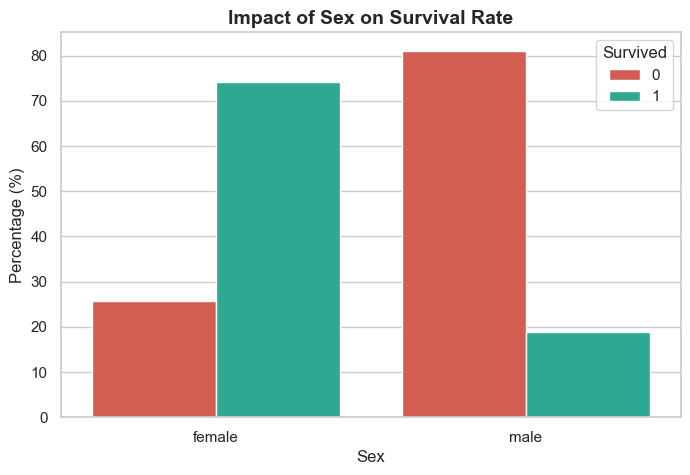

In [17]:
# Plot 2: Impact of Sex on Survival Rate
custom_palette = ['#e74c3c', '#1abc9c']
plt.figure(figsize=(8, 5))

# Calculate the percentage of survival per Sex category
sex_survival = df_clean.groupby('Sex')['Survived'].value_counts(normalize=True).rename('Percentage').mul(100).reset_index()

# Create a bar plot to show percentages
sns.barplot(data=sex_survival, x='Sex', y='Percentage', hue='Survived', palette=custom_palette)

# Add titles and labels
plt.title('Impact of Sex on Survival Rate', fontsize=14, fontweight='bold')
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.show()

**Insight:** Female passengers survived at a dramatically higher rate than male passengers, consistent with "women and children first" evacuation protocol.

**Recommendation:** Sex is one of the strongest single predictors of survival and should be a core feature in any predictive model.

**Business Question:** Does passenger class (Pclass) influence survival?

**Hypothesis:** First-class passengers have a higher survival rate than second- and third-class passengers.

**Variables:** Pclass (ordinal categorical) vs Survived (categorical)

**Visualization choice:** Grouped bar chart (Categorical vs Categorical).

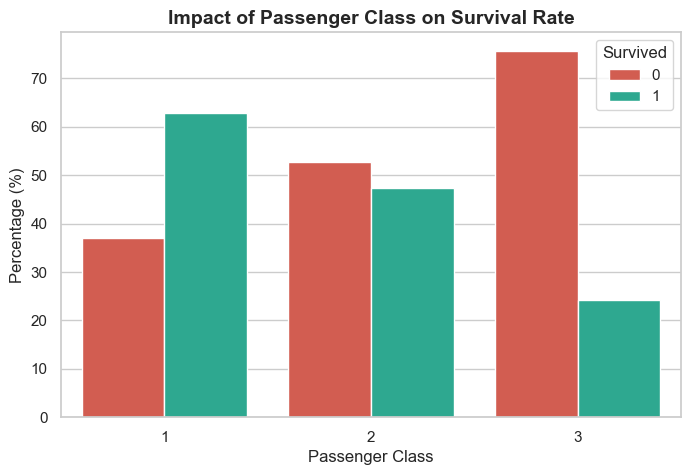

In [18]:
# Plot 3: Impact of Passenger Class on Survival Rate
plt.figure(figsize=(8, 5))

pclass_survival = df_clean.groupby('Pclass')['Survived'].value_counts(normalize=True).rename('Percentage').mul(100).reset_index()

sns.barplot(data=pclass_survival, x='Pclass', y='Percentage', hue='Survived', palette=custom_palette)

plt.title('Impact of Passenger Class on Survival Rate', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.show()

**Insight:** Survival rate decreases steadily from 1st to 3rd class, reflecting both cabin location relative to lifeboats and socio-economic factors in evacuation priority.

**Recommendation:** Pclass (and the related Fare/Deck signals) is a strong socio-economic proxy for survival and should be retained as a core modeling feature.

**Business Question:** Are any numerical features strongly related to each other, which could affect how we interpret their individual relationships with survival?

**Hypothesis:** Family-related features (SibSp, Parch, FamilySize) are strongly positively correlated with each other, and Fare is positively correlated with Pclass (inversely, since Pclass 1 = most expensive).

**Variables:** Multiple numerical features (Numerical vs Numerical)

**Visualization choice:** Correlation heatmap.

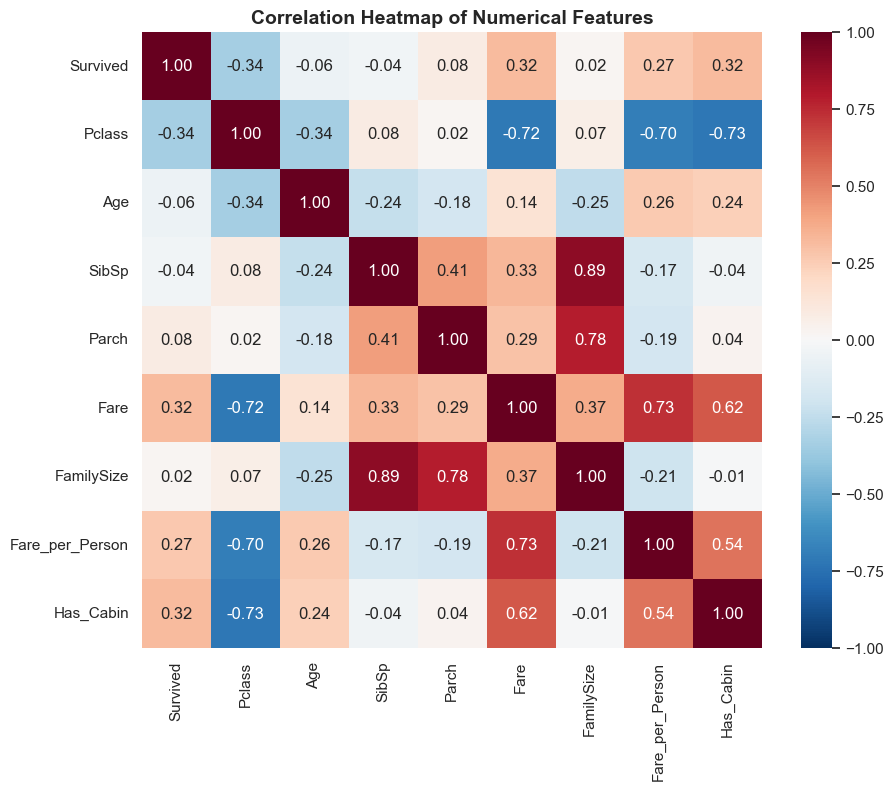

In [19]:
# Plot 4: Correlation Heatmap for Key Numerical Columns
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Fare_per_Person', 'Has_Cabin']

plt.figure(figsize=(10, 8))

# Calculate the correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# Create a heatmap with a diverging color map (Red-Blue)
sns.heatmap(corr_matrix,
            annot=True,
            cmap='RdBu_r',
            fmt=".2f",
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.show()

**Insight:** SibSp, Parch, and FamilySize are strongly correlated with each other (by construction), and Fare shows a meaningful negative correlation with Pclass.

**Recommendation:** Be cautious about using SibSp, Parch, and FamilySize together in the same model (multicollinearity); consider keeping the engineered FamilySize/IsAlone features instead of all three raw components.

**Business Question:** Does an passenger's age influence their chance of survival?

**Hypothesis:** Younger passengers (children) have a higher survival rate than older passengers.

**Variables:** Age (numerical) vs Survived (categorical)

**Visualization choice:** Boxplot (Numerical vs Categorical).

C:\Users\Abdo Tamer\AppData\Local\Temp\ipykernel_12304\3877344783.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Survived', y='Age', palette=custom_palette)


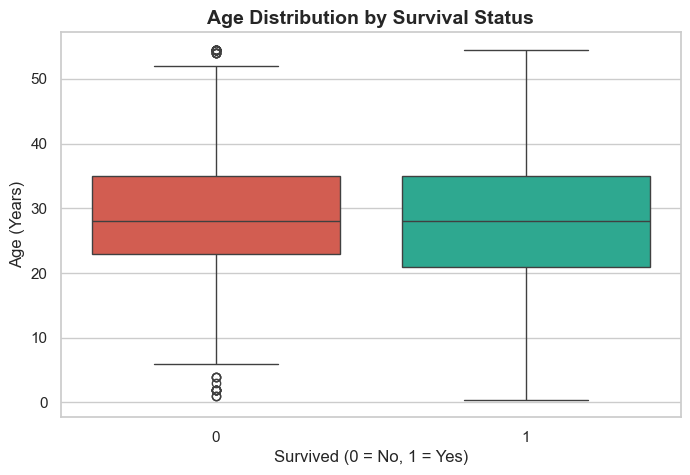

In [20]:
# Plot 5: Age Distribution by Survival Status
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x='Survived', y='Age', palette=custom_palette)

plt.title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Survived (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Age (Years)', fontsize=12)
plt.show()

**Insight:** The age distributions largely overlap, but survivors skew slightly younger, with a visibly higher concentration of young children among survivors.

**Recommendation:** Age alone is a weak predictor, but combined with AgeGroup (especially the "Child" bucket) it adds useful signal on top of Sex and Pclass.

**Business Question:** Does fare (a proxy for wealth/cabin location) affect survival?

**Hypothesis:** Passengers who paid a higher fare are more likely to have survived.

**Variables:** Fare (numerical) vs Survived (categorical)

**Visualization choice:** KDE / density plot (Numerical vs Categorical).

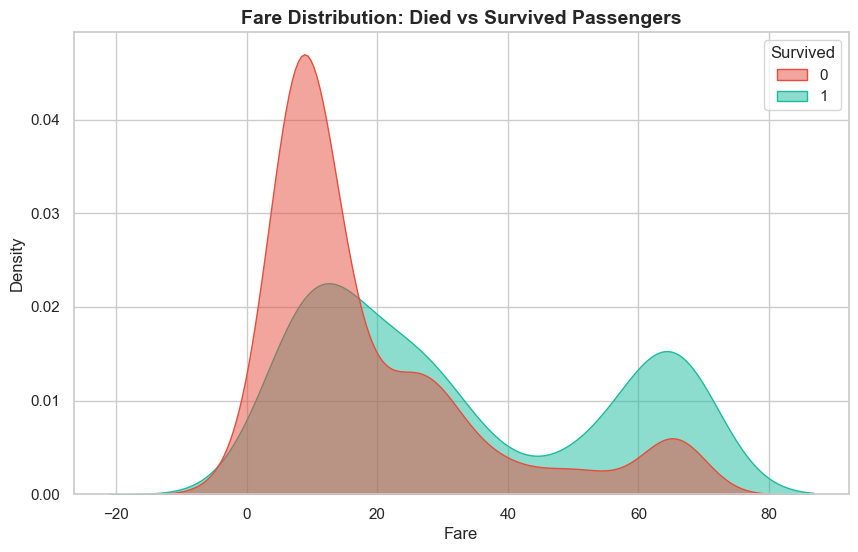

In [21]:
# Plot 6: Fare Distribution (Died vs Survived)
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_clean, x='Fare', hue='Survived', fill=True, palette=custom_palette, common_norm=False, alpha=0.5)

plt.title('Fare Distribution: Died vs Survived Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Fare', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

**Insight:** Survivors are noticeably concentrated at higher fare values, reinforcing that wealthier passengers (mostly 1st class) had better survival odds.

**Recommendation:** Combine Fare with Pclass and Deck/Has_Cabin signals for a fuller socio-economic picture in modeling.

**Business Question:** Does family size, or travelling alone, affect survival?

**Hypothesis:** Passengers travelling completely alone have a lower survival rate than those with a small family, while very large families also survive less (harder to coordinate evacuation).

**Variables:** FamilySize / IsAlone (categorical/ordinal) vs Survived (categorical)

**Visualization choice:** Bar chart (Categorical vs Categorical).

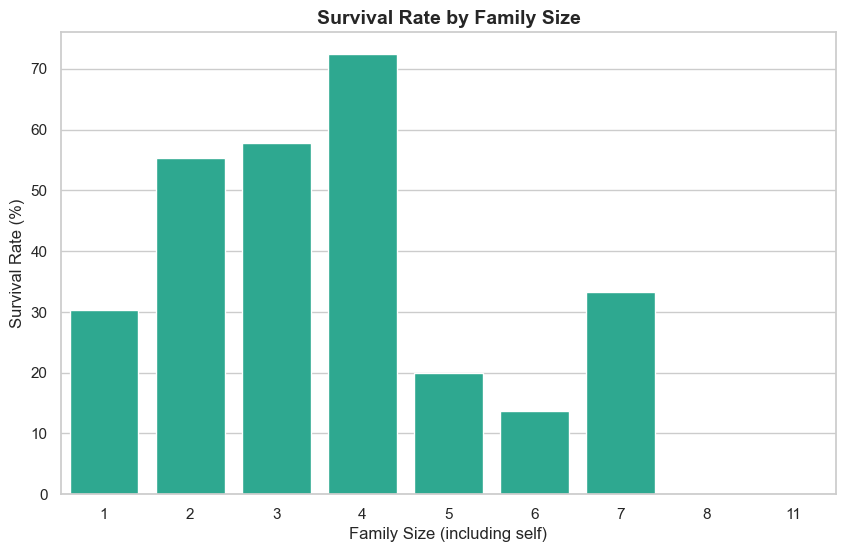

In [22]:
# Plot 7: Family Size vs Survival Rate
plt.figure(figsize=(10, 6))

family_survival = df_clean.groupby('FamilySize')['Survived'].mean().mul(100).reset_index()

sns.barplot(data=family_survival, x='FamilySize', y='Survived', color='#1abc9c')

plt.title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
plt.xlabel('Family Size (including self)', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)
plt.show()

**Insight:** Passengers travelling completely alone (FamilySize = 1) and those in very large families (6+) show the lowest survival rates; small families of 2-4 survive at the highest rates.

**Recommendation:** Use the engineered FamilySize / IsAlone features (rather than raw SibSp/Parch alone) as a compact, model-friendly signal of this non-linear relationship.

**Business Question:** Does a passenger's social title (extracted from Name) add predictive signal beyond Sex and Age?

**Hypothesis:** Titles tied to social status or age (e.g. "Master" for young boys, "Mrs"/"Miss") show different survival rates even within the same Sex.

**Variables:** Title (categorical, engineered) vs Survived (categorical)

**Visualization choice:** Grouped/stacked count plot (Categorical vs Categorical).

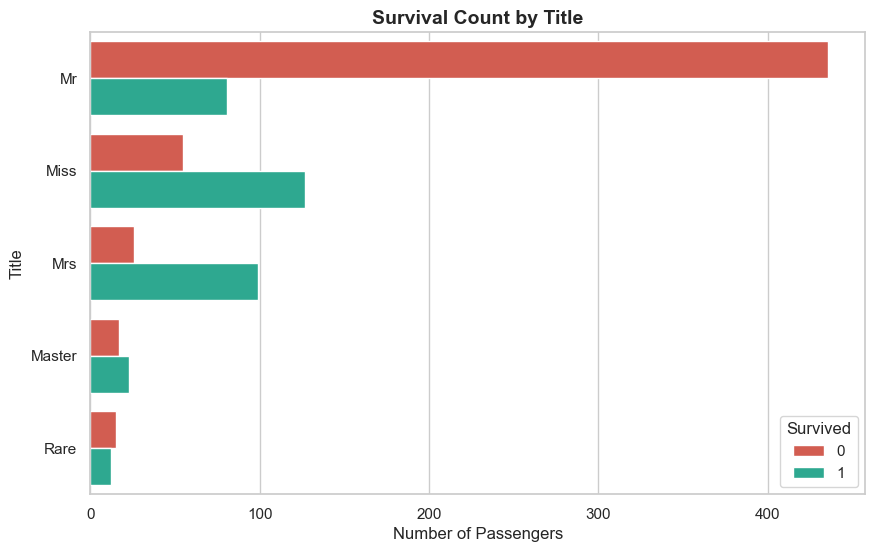

In [23]:
# Plot 8: Survival Count by Title
plt.figure(figsize=(10, 6))

sns.countplot(data=df_clean, y='Title', hue='Survived', palette=custom_palette, order=df_clean['Title'].value_counts().index)

plt.title('Survival Count by Title', fontsize=14, fontweight='bold')
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Title', fontsize=12)
plt.show()

**Insight:** "Mrs" and "Miss" show the highest survival rates, "Master" (young boys) survives notably better than "Mr", and "Mr" has by far the lowest survival rate of any title.

**Recommendation:** Title is a compact engineered feature that captures both sex and age-related social status in one column, and is worth keeping alongside (or even instead of) raw Sex/Age in a model.

### 4) Prepare Featuers

#### 1. Encoding

In [24]:
# Map Ordinal/binary feature (Sex) to 0 and 1
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked (nominal, no natural order)
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True, dtype=int)

# One-hot encode Title (nominal)
df_clean = pd.get_dummies(df_clean, columns=['Title'], drop_first=True, dtype=int)

# One-hot encode AgeGroup (nominal, engineered)
df_clean = pd.get_dummies(df_clean, columns=['AgeGroup'], drop_first=True, dtype=int)

df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,IsAlone,Fare_per_Person,Embarked_Queenstown,Embarked_Southampton,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Child,AgeGroup_Teen
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,0,3.6250,0,1,0,1,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,65.6344,...,0,32.8172,0,0,0,0,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,1,7.9250,0,1,1,0,0,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,0,26.5500,0,1,0,0,1,0,0,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,1,8.0500,0,1,0,1,0,0,0,0


#### 2. Scale

In [25]:
numerical_cols = [
    'Age', 'SibSp', 'Parch', 'Fare',
    'FamilySize', 'Fare_per_Person'
]

scaler = MinMaxScaler()
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])

df_clean[['FamilySize', 'IsAlone', 'Fare_per_Person', 'Has_Cabin']].head()

,FamilySize,IsAlone,Fare_per_Person,Has_Cabin
0,0.1,0,0.055230,0
1,0.1,0,0.500000,1
2,0.0,1,0.120745,0
3,0.1,0,0.404513,1
4,0.0,1,0.122649,0


## 5) Executive Summary & Business Recommendations

### Titanic Survival Analysis Summary

**Context:** This analysis explores the RMS Titanic passenger manifest to understand which factors were most strongly associated with survival, following the same clean → engineer → explore → prepare workflow used in the HR attrition project.

### 1. Sex Influence on Survival
**Question:** How much does a passenger's sex influence their odds of survival?
*   **Insight:** Sex is the single strongest predictor of survival — women survived at a far higher rate than men.
*   **Details:** The "women and children first" evacuation protocol produced a stark gap between male and female survival rates.
*   **Recommendation:** Any predictive model should treat Sex as a top-tier feature; class-level analysis should always be broken out by Sex first.

---

### 2. Impact of Passenger Class
**Question:** Did travelling in a higher class actually improve survival odds?
*   **Insight:** Yes — survival rate drops steadily from 1st to 3rd class.
*   **Details:** 1st class passengers were closer to the boat deck and were prioritized during evacuation; 3rd class passengers faced both physical and procedural disadvantages.
*   **Recommendation:** Keep Pclass, Fare, and Has_Cabin together as a socio-economic feature group rather than relying on just one of them.

---

### 3. Age and Family Size
**Question:** Did age and travelling with family change a passenger's chances?
*   **Insight:** Young children had a survival advantage, and passengers in small families (2-4 people) fared better than those travelling completely alone or in very large families.
*   **Details:** The engineered FamilySize and IsAlone features expose a non-linear relationship that raw SibSp/Parch alone did not make as clear.
*   **Recommendation:** Use the engineered tenure-style features (FamilySize, IsAlone, AgeGroup) as compact, model-ready signals of this pattern.

---

### 4. Fare and Cabin Availability
**Question:** How does Fare correlate with the decision outcome of survival?
*   **Insight:** Higher fares are associated with materially higher survival rates.
*   **Details:** Fare acts as a proxy for both cabin class and cabin location relative to lifeboats; passengers with a recorded Cabin (Has_Cabin = 1) survived at a higher rate than those without one on record.
*   **Recommendation:** Retain Fare_per_Person and Has_Cabin as engineered features that reduce the noise from raw Fare and sparse raw Cabin values.

---

### 5. Engineered Features Insight
**Question:** Do the engineered features add anything beyond the raw variables?
*   **Insight:** Title (extracted from Name) captures a compact mix of sex, age, and social status that raw Sex/Age alone don't fully express — "Master" (young boys) clearly outperforms "Mr", for example.
*   **Details:** Combining Title with FamilySize/IsAlone surfaces distinct at-risk and advantaged segments that aren't obvious from any single raw feature.
*   **Recommendation:** Use these engineered indicators (Title, FamilySize, IsAlone, Fare_per_Person, Has_Cabin, AgeGroup) as the core feature set for any downstream classification model.

---

### Executive Summary
Based on the data analysis, the **"highest-risk" profile** for not surviving is an adult male in 3rd class, travelling alone or with a very large family, holding a low-fare ticket with no recorded cabin.

**Key Strategic Takeaways:**
1. Sex and Pclass are the two dominant survival drivers and should anchor any model.
2. Family composition (FamilySize/IsAlone) adds meaningful non-linear signal beyond raw SibSp/Parch.
3. Engineered socio-economic indicators (Fare_per_Person, Has_Cabin) sharpen the raw Fare/Cabin signal.
4. Title is a compact, high-value engineered feature worth prioritizing in feature selection.

**Expected Impact & Next Steps:** These engineered features (Title, FamilySize, IsAlone, Fare_per_Person, Has_Cabin, AgeGroup) form a strong, leakage-free baseline feature set for a survival classification model. Suggested next steps: train a baseline classifier (e.g. Logistic Regression or Random Forest) on this prepared dataset and evaluate with stratified cross-validation given the class imbalance identified in the EDA.